In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [5]:
import joblib

In [6]:
df = pd.read_csv("fake_job_postings.csv")

In [7]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [9]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [10]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [11]:
text_columns = [
    "title",
    "description",
    "requirements",
    "company_profile",
    "benefits"
]

for col in text_columns:
    df[col + "_length"] = df[col].fillna("").astype(str).str.len()


df["has_email"] = df["description"].fillna("").str.contains(
    r"\S+@\S+", regex=True
).astype(int)

df["has_url"] = df["description"].fillna("").str.contains(
    r"http|www\.", case=False, regex=True
).astype(int)

In [12]:
df[
    [
        "title",
        "title_length",
        "description_length",
        "requirements_length",
        "company_profile_length",
        "benefits_length",
        "has_email",
        "has_url"
    ]
].head()

,title,title_length,description_length,requirements_length,company_profile_length,benefits_length,has_email,has_url
0,Marketing Intern,16,905,852,885,0,0,0
1,Customer Service - Cloud Video Production,41,2077,1433,1286,1292,0,1
2,Commissioning Machinery Assistant (CMA),39,355,1363,879,0,0,0
3,Account Executive - Washington DC,33,2600,1429,614,782,0,0
4,Bill Review Manager,19,1520,757,1628,21,0,0


In [13]:
selected_features = [
    "title_length",
    "description_length",
    "requirements_length",
    "company_profile_length",
    "benefits_length",
    "has_email",
    "has_url",
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

X = df[selected_features].copy()
y = df["fraudulent"].copy()

categorical_features = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

X[categorical_features] = X[categorical_features].fillna("Unknown")

X = pd.get_dummies(
    X,
    columns=categorical_features,
    dtype=int
)

print("Original dataset shape :", df.shape)
print("Model feature shape    :", X.shape)
print("Target shape           :", y.shape)

Original dataset shape : (17880, 25)
Model feature shape    : (17880, 208)
Target shape           : (17880,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data :", X_train.shape)
print("Testing data  :", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)

Training data : (14304, 208)
Testing data  : (3576, 208)
Training target: (14304,)
Testing target : (3576,)


In [15]:
model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions generated:", len(y_pred))

Predictions generated: 3576


In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

Accuracy: 0.9720357941834452

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3403
           1       0.83      0.53      0.65       173

    accuracy                           0.97      3576
   macro avg       0.90      0.76      0.82      3576
weighted avg       0.97      0.97      0.97      3576



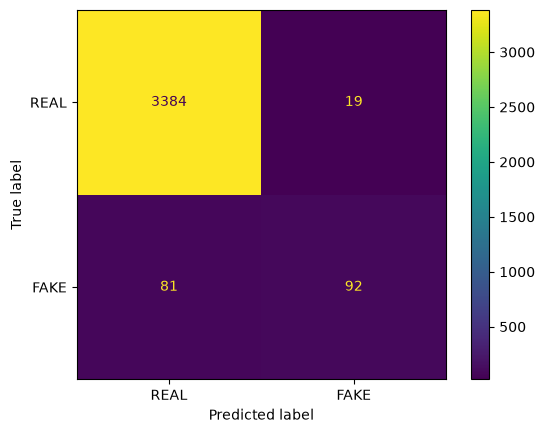

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["REAL", "FAKE"]
)

disp.plot()
plt.show()

                        Feature  Importance
3        company_profile_length    0.210734
1            description_length    0.124782
171     function_Administrative    0.080606
126       industry_Oil & Energy    0.072630
0                  title_length    0.055644
..                          ...         ...
201              function_Sales    0.000000
203  function_Strategy/Planning    0.000000
204       function_Supply Chain    0.000000
205           function_Training    0.000000
207    function_Writing/Editing    0.000000

[208 rows x 2 columns]


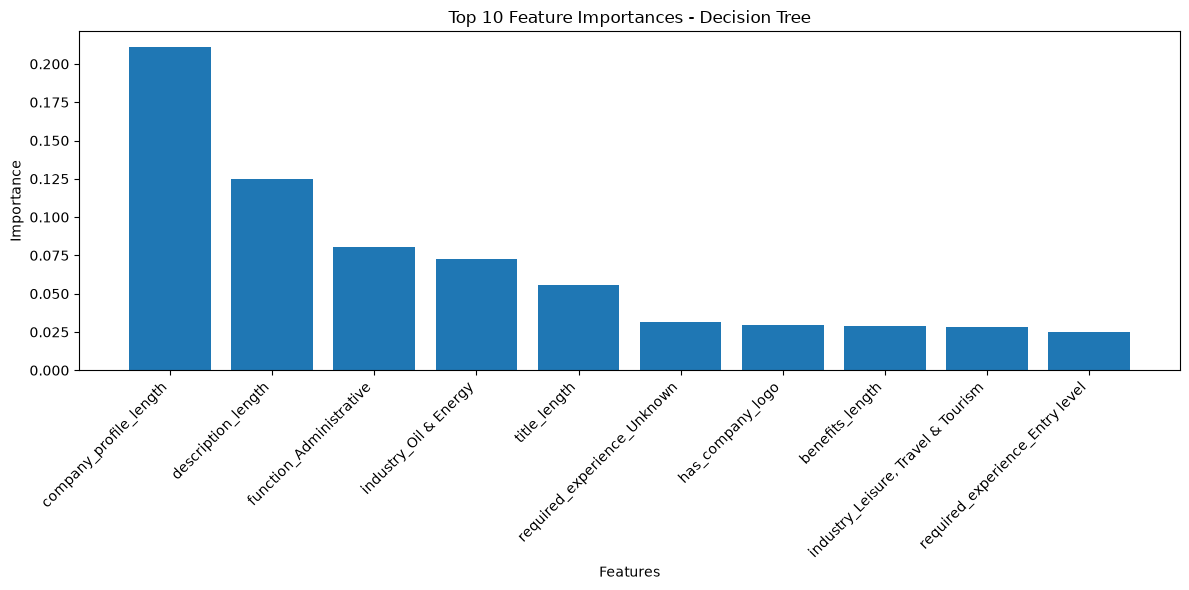

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

top_features = feature_importance.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# ACTUAL FAKE JOB POSTING DETECTION STARTS 

In [20]:
new_job = {
    "title": "Software Engineer",
    "description": "We are looking for a software engineer to join our development team. The candidate will work on building and maintaining web applications.",
    "requirements": "Bachelor's degree in Computer Science with 1-2 years of programming experience. Knowledge of Python and SQL is preferred.",
    "company_profile": "Our company develops software solutions for businesses and provides a professional working environment.",
    "benefits": "Health insurance, paid leave, flexible working hours and professional development opportunities.",
    "employment_type": "Full-time",
    "required_experience": "Entry level",
    "required_education": "Bachelor's Degree",
    "industry": "Computer Software",
    "function": "Engineering",
    "telecommuting": 0,
    "has_company_logo": 1,
    "has_questions": 1
}

new_job

{'title': 'Software Engineer',
 'description': 'We are looking for a software engineer to join our development team. The candidate will work on building and maintaining web applications.',
 'requirements': "Bachelor's degree in Computer Science with 1-2 years of programming experience. Knowledge of Python and SQL is preferred.",
 'company_profile': 'Our company develops software solutions for businesses and provides a professional working environment.',
 'benefits': 'Health insurance, paid leave, flexible working hours and professional development opportunities.',
 'employment_type': 'Full-time',
 'required_experience': 'Entry level',
 'required_education': "Bachelor's Degree",
 'industry': 'Computer Software',
 'function': 'Engineering',
 'telecommuting': 0,
 'has_company_logo': 1,
 'has_questions': 1}

In [21]:
new_df = pd.DataFrame([new_job])

new_df

,title,description,requirements,company_profile,benefits,employment_type,required_experience,required_education,industry,function,telecommuting,has_company_logo,has_questions
0,Software Engineer,We are looking for a software engineer to join...,Bachelor's degree in Computer Science with 1-2...,Our company develops software solutions for bu...,"Health insurance, paid leave, flexible working...",Full-time,Entry level,Bachelor's Degree,Computer Software,Engineering,0,1,1


In [22]:
text_columns = [
    "title",
    "description",
    "requirements",
    "company_profile",
    "benefits"
]

for col in text_columns:
    new_df[col + "_length"] = new_df[col].fillna("").astype(str).str.len()

new_df[[
    "title",
    "title_length",
    "description_length",
    "requirements_length",
    "company_profile_length",
    "benefits_length"
]]

,title,title_length,description_length,requirements_length,company_profile_length,benefits_length
0,Software Engineer,17,138,121,103,96


In [23]:
[name for name in globals() if "encoder" in name.lower()]

[]

In [24]:
feature_columns = X.columns.tolist()

print("Total model features:", len(feature_columns))
print("First 10 features:")
print(feature_columns[:10])

Total model features: 208
First 10 features:
['title_length', 'description_length', 'requirements_length', 'company_profile_length', 'benefits_length', 'has_email', 'has_url', 'telecommuting', 'has_company_logo', 'has_questions']


In [25]:
for col in text_columns:
    new_df[col + "_length"] = new_df[col].fillna("").astype(str).str.len()

new_df["has_email"] = new_df["description"].fillna("").str.contains(
    r"\S+@\S+", regex=True
).astype(int)

new_df["has_url"] = new_df["description"].fillna("").str.contains(
    r"http|www\.", case=False, regex=True
).astype(int)

new_df[categorical_features] = new_df[categorical_features].fillna("Unknown")

new_df = pd.get_dummies(
    new_df,
    columns=categorical_features,
    dtype=int
)

new_df = new_df.reindex(columns=feature_columns, fill_value=0)

print("New job feature shape:", new_df.shape)

New job feature shape: (1, 208)


In [26]:
prediction = model.predict(new_df)

if prediction[0] == 0:
    print("Prediction: REAL JOB")
else:
    print("Prediction: FAKE JOB")

Prediction: REAL JOB


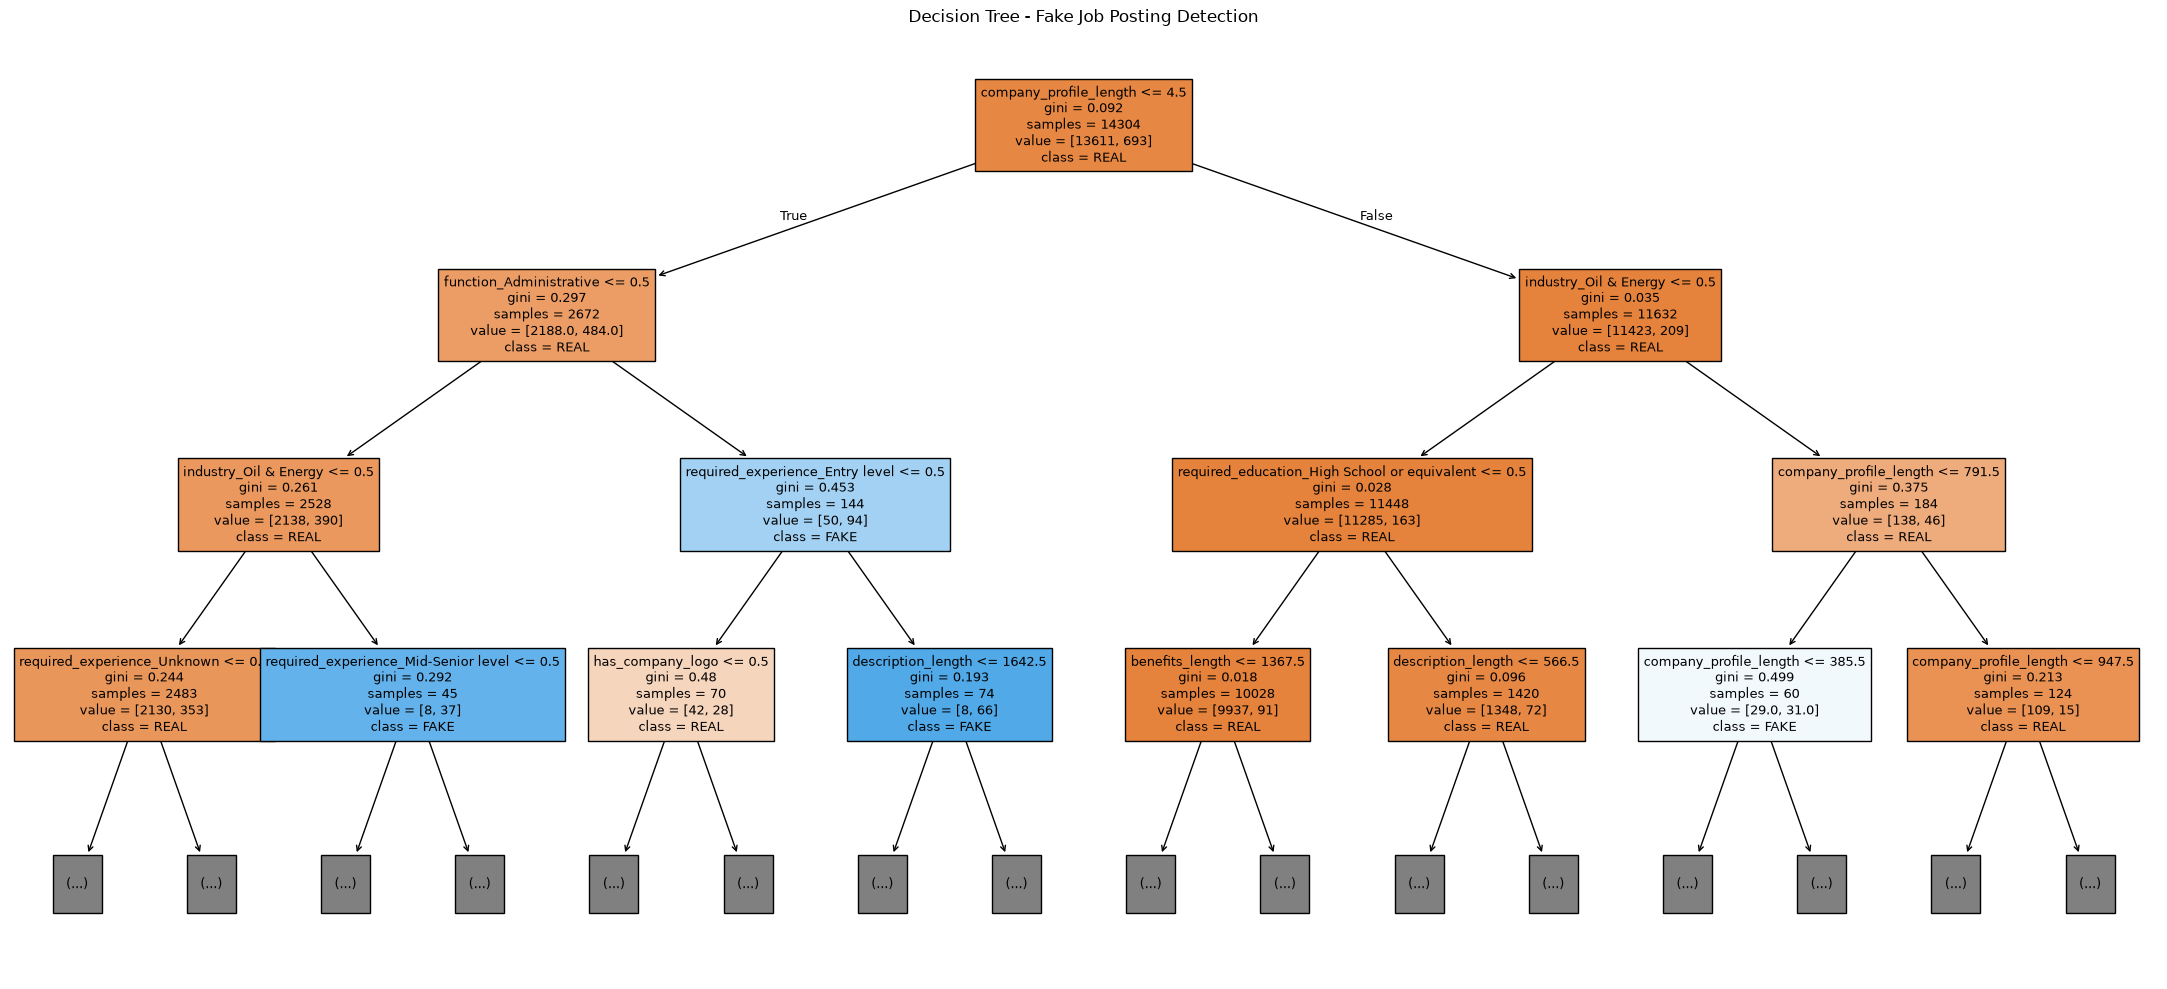

In [27]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 10))

plot_tree(
    model,
    feature_names=X_train.columns,
    class_names=["REAL", "FAKE"],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree - Fake Job Posting Detection")
plt.tight_layout()
plt.show()

In [28]:
import joblib

joblib.dump(model, "fake_job_model.pkl")
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("Model and feature information saved successfully.")

Model and feature information saved successfully.


In [ ]:
## Limitations

Although the Decision Tree model achieved high overall accuracy, the system has several limitations:

1. **Class Imbalance:** The dataset contains significantly more real job postings than fraudulent postings, which can affect model evaluation.

2. **Lower Fraud Recall:** The model achieved a recall of approximately 0.53 for fraudulent job postings. Therefore, some fraudulent postings may still be classified as real.

3. **Limited Text Understanding:** The current model mainly uses engineered features such as text length and categorical information rather than understanding the semantic meaning of the job description.

4. **Dataset Dependency:** The model learns patterns from the available dataset, so its performance may vary when applied to job postings from different platforms or time periods.

5. **Limited External Validation:** The model was evaluated using a train-test split from the same dataset. Testing on an independent external dataset would provide stronger evidence of real-world performance.

In [ ]:
## Conclusion

This project developed a Decision Tree based machine learning model to detect fraudulent job postings. The model uses job-related features such as text length, company information, employment details, industry, and experience requirements to classify postings as REAL or FAKE.

The model achieved an overall accuracy of approximately 97.2% on the test dataset. The project demonstrates how machine learning can be applied to identify suspicious job postings and assist in reducing the risk of online recruitment fraud.